# UFEA 26년 상반기 16주차 실습과제
# Quanto Option Pricing — USDKRW → JPY

## 상품 구조
| 항목 | 값 |
|---|---|
| 기초자산 (CCY1/CCY2) | USD/KRW |
| 콴토 통화 (CCY3) | JPY |
| 페이오프 | max(S_T − K, 0) [JPY 지급] |
| σ₁ | USDKRW vol (SABR 곡면, Jewitt CCY1/CCY2) |
| σ₂ | JPYKRW vol (Jewitt CCY3/CCY2) |
| ρ | corr(USDKRW, JPYKRW) — 삼각관계 implied |
| 할인 | JPY 금리 (JGB bootstrap) |

## Jewitt 콴토 SDE (p.554)
$$\frac{dS_t}{S_t} = (r_{KRW} - r_{USD} - \rho\cdot\sigma_1\cdot\sigma_2)\,dt + \sigma_1\,dW_t$$

$$F_{quanto} = F \cdot e^{-\rho \cdot \sigma_{1,ATM} \cdot \sigma_2 \cdot T} < F \quad (\because \rho > 0)$$

## 사용 파일
```
market_curves.csv   — df_usd, df_krw, forward (지난 과제 결과물)
sabr_params.csv     — SABR alpha/rho/nu (지난 과제 결과물)
jgbcme_all.csv      — JGB par yield (JPY 커브용)
CURNCY_VOL.csv      — ATM vol 스냅샷 (σ₂, implied ρ 역산용)
usdkrw_spot.csv     — USDKRW 일별 종가 (historical ρ 검증용)
usdjpy_spot.csv     — USDJPY 일별 종가 (historical ρ 검증용)
jpykrw_spot.csv     — JPYKRW 일별 종가 (historical ρ 검증용)
```

---
## §0. 라이브러리 & 설정

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.interpolate import interp1d
from scipy.stats import norm

# ── 파일 경로 ─────────────────────────────────────────────────────────────
MARKET_CURVES_FILE = 'market_curves.csv'
SABR_PARAMS_FILE   = 'sabr_params.csv'
JGB_FILE           = 'jgbcme_all.csv'
VOL_FILE           = 'CURNCY_VOL.csv'
USDKRW_FILE        = 'usdkrw_spot.csv'
USDJPY_FILE        = 'usdjpy_spot.csv'
JPYKRW_FILE        = 'jpykrw_spot.csv'

# ── 상수 ─────────────────────────────────────────────────────────────────
BETA         = 1.0
S0           = 1352.93    # USDKRW spot (2023-09-26)
TRADING_DAYS = 252

# ── 차트 스타일 ───────────────────────────────────────────────────────────
C = {'krw':'#4C9BE8','jpy':'#54C17A','quanto':'#A66CEB',
     'bs':'#E85454','mc':'#E8834C','line':'#888888','hist':'#F5C542'}

def stylize(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor('#0F0F0F'); ax.figure.patch.set_facecolor('#1A1A1A')
    ax.tick_params(colors='#CCCCCC')
    ax.xaxis.label.set_color('#CCCCCC'); ax.yaxis.label.set_color('#CCCCCC')
    ax.title.set_color('#FFFFFF')
    for s in ax.spines.values(): s.set_edgecolor('#333333')
    ax.grid(True, color='#2A2A2A', lw=0.8)
    if title:  ax.set_title(title, fontsize=12, fontweight='bold')
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

print('설정 완료  |  S0 =', S0)

설정 완료  |  S0 = 1352.93


---
## §1. TODO 1 — 삼각관계 implied ρ 및 σ₂ 역산

### 힌트
- `CURNCY_VOL.csv`에서 USDKRW/USDJPY/JPYKRW ATM vol을 읽어옵니다
- Jewitt 정의: σ₂ = **JPYKRW** vol (CCY3/CCY2), σ_cross = USDJPY vol
- 삼각관계 공식: ln(JPYKRW) = ln(USDKRW) − ln(USDJPY) 이므로
$$\rho = \frac{\sigma_{USDKRW}^2 + \sigma_{JPYKRW}^2 - \sigma_{USDJPY}^2}{2 \cdot \sigma_{USDKRW} \cdot \sigma_{JPYKRW}}$$
- σ₂ 보간 시 **Total Variance(σ²·T)를 선형 보간**한 뒤 역산해야 Calendar Arbitrage 방지
  - `tv = σ² × T` 를 보간 → `σ = sqrt(tv / T)`
- historical ρ는 USDKRW × JPYKRW log return의 rolling correlation으로 계산 (Jewitt 정의와 동일 기준)

### 1-A. ATM Vol 파싱

In [8]:
raw_vol = pd.read_csv(VOL_FILE)
vol_dict = {}
for _, row in raw_vol.iterrows():
    key = row['TICKER'].strip()
    val = float(row['09/26/23']) / 100
    vol_dict[key] = val

TENOR_MAP = {'1M': 1/12, '3M': 3/12, '6M': 6/12, '1Y': 1.0}

# ── TODO 1-A: 만기별 ATM vol 딕셔너리 구성 ───────────────────────────────
# Jewitt 정의:
#   σ₁ = USDKRW ATM vol  (CCY1/CCY2)
#   σ₂ = JPYKRW ATM vol  (CCY3/CCY2) ← 핵심
#   σ_cross = USDJPY ATM vol (삼각관계 역산용)

sigma1_atm  = {}   # σ₁: USDKRW
sigma2_atm  = {}   # σ₂: JPYKRW  ← Jewitt CCY3/CCY2
sigma_cross = {}   # σ_cross: USDJPY (삼각관계 역산용)

# ===== 구현 =====
# vol_dict 키는 .strip() 처리됨:
#   'USDKRW {t} ATM VOL', 'USDJPY {t} ATM VOL Curncy', 'JPYKRW {t} ATM VOL'
for t in ['1M', '3M', '6M', '1Y']:
    sigma1_atm[t]  = vol_dict[f'USDKRW {t} ATM VOL']
    sigma_cross[t] = vol_dict[f'USDJPY {t} ATM VOL Curncy']
for t in ['1M', '3M', '1Y']:          # JPYKRW 는 6M 호가 없음
    sigma2_atm[t]  = vol_dict[f'JPYKRW {t} ATM VOL']
# ================

print('ATM Vol (2023-09-26):')
print(f'  {"Tenor":>4}  {"σ₁ USDKRW":>12}  {"σ₂ JPYKRW":>12}  {"σ_cross USDJPY":>16}')
for t in ['1M', '3M', '6M', '1Y']:
    s1  = sigma1_atm.get(t, float('nan'))
    s2  = sigma2_atm.get(t, float('nan'))
    sc  = sigma_cross.get(t, float('nan'))
    print(f'  {t:>4}  {s1*100 if not np.isnan(s1) else float("nan"):>11.2f}%'
          f'  {s2*100 if not np.isnan(s2) else float("nan"):>11.2f}%'
          f'  {sc*100 if not np.isnan(sc) else float("nan"):>15.2f}%')

ATM Vol (2023-09-26):
  Tenor     σ₁ USDKRW     σ₂ JPYKRW    σ_cross USDJPY
    1M         8.96%         9.50%             8.40%
    3M         8.85%         9.80%             9.32%
    6M         8.94%          nan%             9.45%
    1Y         9.20%        10.25%             9.47%


### 1-B. Implied ρ 역산 & σ₂ Total Variance 보간

In [9]:
# ── TODO 1-B: 삼각관계 implied ρ 역산 ───────────────────────────────────
# 공식: ρ = (σ₁² + σ₂² - σ_cross²) / (2 · σ₁ · σ₂)
# 1M, 3M, 1Y 세 만기 (6M은 JPYKRW 없음 → 보간 처리)

rho_implied = {}

# ===== 구현 =====
for t in ['1M', '3M', '1Y']:
    s1 = sigma1_atm[t]    # USDKRW
    s2 = sigma2_atm[t]    # JPYKRW
    sc = sigma_cross[t]   # USDJPY
    rho_implied[t] = (s1**2 + s2**2 - sc**2) / (2 * s1 * s2)
# ================

print('Implied ρ = corr(USDKRW, JPYKRW):')
for t in ['1M', '3M', '1Y']:
    if t in rho_implied:
        print(f'  {t}: ρ = {rho_implied[t]:.4f}')

# ── TODO 1-B: σ₂ Total Variance 보간 함수 구성 ───────────────────────────
# σ 직접 보간 시 Calendar Arbitrage 발생 가능
# TV = σ²×T 를 선형보간 후 역산: σ = sqrt(TV / T)

# ===== 구현 =====
T_s2_arr = np.array([TENOR_MAP[t] for t in sigma2_atm])
tv_s2    = np.array([sigma2_atm[t]**2 * TENOR_MAP[t] for t in sigma2_atm])   # σ²×T
_tv_s2_interp = interp1d(T_s2_arr, tv_s2, kind='linear', fill_value='extrapolate')
# ================

def get_sigma2(T_):
    # ===== 구현 =====
    T_ = float(T_)
    tv = float(_tv_s2_interp(T_))
    return float(np.sqrt(max(tv, 1e-12) / max(T_, 1e-8)))
    # ================

# ── ρ 보간 함수 ───────────────────────────────────────────────────────────
T_rho = np.array([TENOR_MAP[t] for t in rho_implied])
rho_v = np.array([rho_implied[t] for t in rho_implied])
rho_interp = interp1d(T_rho, rho_v, kind='linear', fill_value='extrapolate')

def get_rho(T_):
    return float(np.clip(rho_interp(float(T_)), -0.9999, 0.9999))

# 검증
print()
print('σ₂ Total Variance 보간 검증:')
print(f'  {"T":>6}  {"σ₂(%)":>8}  {"TV=σ²·T":>10}  비고')
for t_str, T_ in [('1M',1/12),('3M',3/12),('6M',6/12),('1Y',1.0),('2Y',2.0)]:
    s2 = get_sigma2(T_) if get_sigma2(T_) else float('nan')
    tv = s2**2 * T_ if s2 else float('nan')
    note = '(관측값)' if t_str in sigma2_atm else '(TV 보간)'
    print(f'  {T_:>6.3f}  {s2*100 if s2 else float("nan"):>7.3f}%  {tv:>10.6f}  {note}')

Implied ρ = corr(USDKRW, JPYKRW):
  1M: ρ = 0.5872
  3M: ρ = 0.5044
  1Y: ρ = 0.5303

σ₂ Total Variance 보간 검증:
       T     σ₂(%)     TV=σ²·T  비고
   0.083    9.500%    0.000752  (관측값)
   0.250    9.800%    0.002401  (관측값)
   0.500   10.102%    0.005103  (TV 보간)
   1.000   10.250%    0.010506  (관측값)
   2.000   10.323%    0.021313  (TV 보간)


### 1-C. Historical ρ — 검증용

Historical ρ(USDKRW, JPYKRW) = 0.4284  ← Jewitt 정의 ✅

Implied vs Historical ρ 비교:
  1M implied = 0.5872
  3M implied = 0.5044
  1Y implied = 0.5303
  1Y hist   = 0.4284


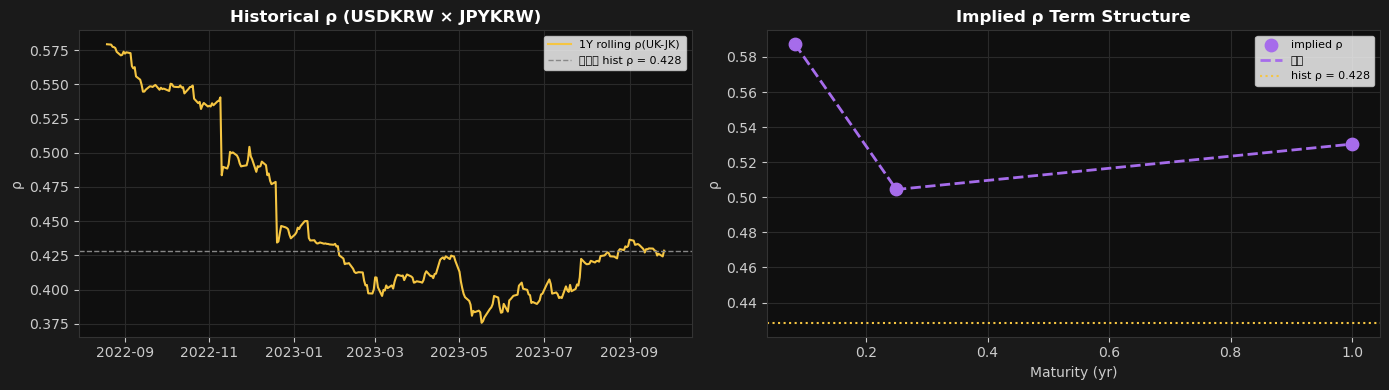

In [11]:
def load_spot(filepath):
    df = pd.read_csv(filepath)
    df['날짜'] = pd.to_datetime(df['날짜'].str.strip(), format='%Y- %m- %d')
    df['종가'] = pd.to_numeric(
        df['종가'].astype(str).str.replace(',', ''), errors='coerce')
    return df.dropna(subset=['종가']).sort_values('날짜').set_index('날짜')['종가']

usdkrw_ts = load_spot(USDKRW_FILE)
usdjpy_ts = load_spot(USDJPY_FILE)
jpykrw_ts = load_spot(JPYKRW_FILE)

lr_krw = np.log(usdkrw_ts).diff().dropna()
lr_jpy = np.log(usdjpy_ts).diff().dropna()
lr_jkr = np.log(jpykrw_ts).diff().dropna()

# ── TODO 1-C: historical ρ 계산 ───────────────────────────────────────────
# Jewitt 정의와 동일 기준: corr(USDKRW, JPYKRW)
# lr_krw 와 lr_jkr 의 1Y rolling correlation (window=252), 기준일(마지막) 값

# ===== 구현 =====
common       = lr_krw.index.intersection(lr_jkr.index)
rho_hist_ts  = lr_krw.loc[common].rolling(252).corr(lr_jkr.loc[common])
rho_hist_val = float(rho_hist_ts.dropna().iloc[-1])
# ================

print(f'Historical ρ(USDKRW, JPYKRW) = {rho_hist_val:.4f}  ← Jewitt 정의 ✅')
print()
print('Implied vs Historical ρ 비교:')
for t in ['1M', '3M', '1Y']:
    if t in rho_implied:
        print(f'  {t} implied = {rho_implied[t]:.4f}')
print(f'  1Y hist   = {rho_hist_val:.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

common = lr_krw.index.intersection(lr_jkr.index)
rho_hist_ts_plot = lr_krw.loc[common].rolling(252).corr(lr_jkr.loc[common])
axes[0].plot(rho_hist_ts_plot, color=C['hist'], lw=1.5, label='1Y rolling ρ(UK-JK)')
axes[0].axhline(rho_hist_val, color=C['line'], ls='--', lw=1,
                label=f'기준일 hist ρ = {rho_hist_val:.3f}')
stylize(axes[0], 'Historical ρ (USDKRW × JPYKRW)', '', 'ρ')
axes[0].legend(fontsize=8)

T_fine = np.linspace(1/12, 1.0, 100)
T_plot = [TENOR_MAP[t] for t in rho_implied]
axes[1].scatter(T_plot, [rho_implied[t] for t in rho_implied],
                color=C['quanto'], s=80, zorder=5, label='implied ρ')
axes[1].plot(T_fine, [get_rho(t) for t in T_fine],
             color=C['quanto'], lw=2, ls='--', label='보간')
axes[1].axhline(rho_hist_val, color=C['hist'], lw=1.5, ls=':',
                label=f'hist ρ = {rho_hist_val:.3f}')
stylize(axes[1], 'Implied ρ Term Structure', 'Maturity (yr)', 'ρ')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## §2. TODO 2 — 금리 커브 구축

### 힌트
- USD/KRW 커브는 `market_curves.csv`에서 직접 로딩 (지난 과제 결과물 재사용)
- **JPY 커브는 JGB par yield → bootstrap**으로 직접 구축해야 함
  - 콴토 옵션의 할인은 페이오프 통화(JPY) 금리로 해야 하기 때문
- Curve 클래스: log-linear 보간, `df(T)`, `zero(T)` 메서드
- JGB bootstrap:
  - 1Y 이하: `df = 1 / (1 + par × T)` (단리 근사)
  - 1Y 초과: 기존 DF로 중간 coupon PV 계산 후 역산
  - 연 1회 coupon (annual) 가정

In [12]:
# ── Curve 클래스 (지난 과제와 동일 구조) ─────────────────────────────────
class Curve:
    """Log-linear 보간 할인커브"""
    def __init__(self, T_, df_):
        T_ = np.asarray(T_, float); df_ = np.asarray(df_, float)
        idx = np.argsort(T_); self.T = T_[idx]
        self._f = interp1d(self.T, np.log(df_[idx]),
                           kind='linear', fill_value='extrapolate')
    def df(self, x):  return np.exp(self._f(np.asarray(x, float)))
    def zero(self, x):
        x = np.maximum(np.asarray(x, float), 1e-12)
        return -np.log(self.df(x)) / x
    def zero_pct(self, x): return self.zero(x) * 100

# ── USD / KRW 커브: market_curves.csv 재사용 ─────────────────────────────
mc  = pd.read_csv(MARKET_CURVES_FILE).sort_values('T').reset_index(drop=True)
usd = Curve(mc['T'], mc['df_usd'])
krw = Curve(mc['T'], mc['df_krw'])

print('USD / KRW 커브 확인:')
print(f'  {"T":>6}  {"r_USD":>9}  {"r_KRW":>9}  {"Forward":>10}')
for t in [1/12, 3/12, 6/12, 1.0, 2.0]:
    fwd = S0 * usd.df(t) / krw.df(t)
    print(f'  {t:>6.3f}  {usd.zero_pct(t):>8.3f}%  {krw.zero_pct(t):>8.3f}%  {fwd:>10.2f}')

USD / KRW 커브 확인:
       T      r_USD      r_KRW     Forward
   0.083     5.541%     3.626%     1350.77
   0.250     5.582%     3.498%     1345.90
   0.500     5.529%     3.292%     1337.88
   1.000     5.373%     3.156%     1323.26
   2.000     4.966%     3.115%     1303.75


JPY zero curve 확인:
  T=0.083y  zero=-0.063%
  T=0.250y  zero=-0.063%
  T=0.500y  zero=-0.063%
  T=1.000y  zero=-0.063%
  T=2.000y  zero=0.034%
  T=5.000y  zero=0.318%
  T=10.000y  zero=0.761%


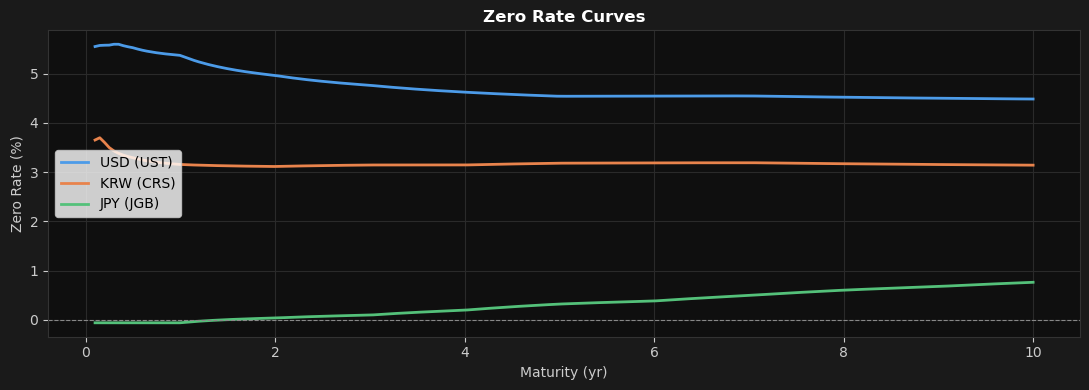

In [13]:
# ── TODO 2: JGB Bootstrap → JPY zero curve ───────────────────────────────
# JGB 파일에서 만기별 par yield 파싱

raw_jgb = pd.read_csv(JGB_FILE)
header  = raw_jgb.iloc[0]; data = raw_jgb.iloc[1]
tenor_map = {f'{i}Y': i for i in range(1, 11)}

jgb_T, jgb_par = [], []
for i, col in enumerate(header.values):
    if col in tenor_map:
        jgb_T.append(tenor_map[col])
        jgb_par.append(float(data.iloc[i]) / 100)

jgb_T   = np.array(jgb_T,   float)
jgb_par = np.array(jgb_par, float)

# ── Bootstrap 함수 구현 ───────────────────────────────────────────────────
def coupon_dates(T_, freq=1):
    """만기까지 coupon 지급 시점 반환"""
    step = 1.0/freq; dates = []; t = step
    while t <= T_ + 1e-9: dates.append(round(t, 6)); t += step
    if not dates or abs(dates[-1] - T_) > 1e-6: dates.append(T_)
    return dates

def bootstrap_jgb(T_arr, par_arr, freq=1):
    """
    JGB par yield → Curve 객체
    - 1Y 이하: df = 1 / (1 + par × T)  (단리 근사)
    - 1Y 초과: 기존 DF로 중간 coupon PV 합산 후 마지막 cashflow로 역산
      → df_T = (1 - pv_coupons) / (1 + c),  c = par/freq
    """
    Ts, dfs = [], []
    for t, par in zip(T_arr, par_arr):
        c   = par / freq
        cds = coupon_dates(t, freq)

        # ===== 구현 =====
        if t <= 1.0 + 1e-9:
            # 단기: 단리 근사로 직접 역산
            df_t = 1.0 / (1.0 + par * t)
        else:
            # 장기: 기존 DF로 중간 coupon PV 계산 후 마지막 cashflow 역산
            tmp  = Curve([0.0] + Ts, [1.0] + dfs)
            pv_c = sum(c * float(tmp.df(s)) for s in cds[:-1])
            df_t = (1.0 - pv_c) / (1.0 + c)
        # ================

        Ts.append(t); dfs.append(max(df_t, 1e-9))
    return Curve([0.0] + Ts, [1.0] + dfs)

# JPY 커브 생성
jpy_curve = bootstrap_jgb(jgb_T, jgb_par)

print('JPY zero curve 확인:')
for t in [1/12, 3/12, 6/12, 1.0, 2.0, 5.0, 10.0]:
    print(f'  T={t:.3f}y  zero={jpy_curve.zero_pct(t):.3f}%')

# 3개 커브 시각화
T_plot = np.linspace(0.1, 10, 200)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(T_plot, usd.zero_pct(T_plot), color=C['krw'], lw=2, label='USD (UST)')
ax.plot(T_plot, krw.zero_pct(T_plot), color=C['mc'],  lw=2, label='KRW (CRS)')
ax.plot(T_plot, jpy_curve.zero_pct(T_plot), color=C['jpy'], lw=2, label='JPY (JGB)')
ax.axhline(0, color=C['line'], lw=0.8, ls='--')
stylize(ax, 'Zero Rate Curves', 'Maturity (yr)', 'Zero Rate (%)')
ax.legend(); plt.tight_layout(); plt.show()

---
## §3. SABR 변동성 곡면 σ₁ (지난 과제 재사용)

In [14]:
# ── SABR Hagan 2002 근사식 ───────────────────────────────────────────────
def sabr_vol(F, K, T, a, b, r, v):
    F=float(F);K=float(K);T=float(T)
    a=float(a);b=float(b);r=float(r);v=float(v)
    T=max(T,1e-8);a=max(a,1e-12)
    r=float(np.clip(r,-0.9999,0.9999));v=max(v,1e-12)
    logFK=np.log(F/K);omb=1-b
    if abs(logFK)<1e-8:
        return (a/F**omb)*(1+((omb**2/24)*a**2/F**(2*omb)
               +(r*b*v*a/4)/F**omb+((2-3*r**2)/24)*v**2)*T)
    FK=F*K;FKb=FK**(omb/2);z=(v/a)*FKb*logFK
    sq=max(1-2*r*z+z*z,0.0);arg=max((np.sqrt(sq)+z-r)/(1-r),1e-10)
    xz=np.log(arg);z_xz=1.0 if abs(xz)<1e-12 else z/xz
    A=a/(FKb*(1+(omb**2/24)*logFK**2+(omb**4/1920)*logFK**4))
    B=((omb**2/24)*a**2/FK**omb+(r*b*v*a/4)/FK**(omb/2)+((2-3*r**2)/24)*v**2)
    return A*z_xz*(1+B*T)

# ── Total Variance 보간으로 SABR 파라미터 로딩 ────────────────────────────
sp = pd.read_csv(SABR_PARAMS_FILE).sort_values('T').reset_index(drop=True)

_iV   = interp1d(sp['T'], sp['alpha']**2 * sp['T'],
                 kind='linear', fill_value='extrapolate')
_irho = interp1d(sp['T'], sp['rho'],  kind='linear', fill_value='extrapolate')
_inu  = interp1d(sp['T'], sp['nu'],   kind='linear', fill_value='extrapolate')
_iF   = interp1d(sp['T'], sp['F'],    kind='linear', fill_value='extrapolate')

def sabr_params_at(T_):
    T_=float(T_); V=float(_iV(T_))
    a=float(np.sqrt(max(V/max(T_,1e-8),1e-12)))
    r=float(np.clip(_irho(T_),-0.9999,0.9999))
    v=float(max(_inu(T_),1e-12))
    return a, r, v

def sigma1(K, T_):
    """SABR σ₁(K,T) — USDKRW implied vol (Jewitt CCY1/CCY2)"""
    F=float(_iF(T_)); a,r,v=sabr_params_at(T_)
    return sabr_vol(F, K, T_, a, BETA, r, v)

print('SABR ATM vol 확인:')
print(f'  {"Tenor":>4}  {"SABR ATM":>10}  {"BBG ATM":>10}  {"차이(bp)":>10}')
for t_str, T_ in [('1M',1/12),('3M',3/12),('6M',6/12),('1Y',1.0)]:
    F_=float(_iF(T_)); sv=sigma1(F_,T_); bv=sigma1_atm.get(t_str,float('nan'))
    diff=(sv-bv)*1e4 if not np.isnan(bv) else float('nan')
    print(f'  {t_str:>4}  {sv*100:>9.3f}%  {bv*100 if not np.isnan(bv) else float("nan"):>9}%  {diff:>9.1f}bp')

SABR ATM vol 확인:
  Tenor    SABR ATM     BBG ATM      차이(bp)
    1M      8.979%       8.96%        1.9bp
    3M      8.850%       8.85%        0.0bp
    6M      8.980%       8.94%        4.0bp
    1Y      9.150%        9.2%       -5.0bp


---
## §4. 콴토 파라미터 집계

In [15]:
T_list = [1/12, 3/12, 6/12, 1.0, 2.0]

rows = []
for T_ in T_list:
    F_   = float(_iF(T_))
    s1   = sigma1(F_, T_)
    s2   = get_sigma2(T_)
    rho  = get_rho(T_)
    rs   = rho * s1 * s2
    F_q  = F_ * np.exp(-rs * T_)
    rows.append({
        'T(yr)'     : round(T_, 4),
        'Forward'   : round(F_, 2),
        'σ₁(%)'     : round(s1*100, 3),
        'σ₂(%)'     : round(s2*100, 3),
        'ρ(implied)': round(rho, 4),
        'ρ·σ₁·σ₂'   : round(rs, 6),
        'F_quanto'  : round(F_q, 2),
        'r_KRW(%)'  : round(krw.zero_pct(T_), 3),
        'r_JPY(%)'  : round(jpy_curve.zero_pct(T_), 3),
    })

param_df = pd.DataFrame(rows)
print('콴토 파라미터 테이블:')
print(param_df.to_string(index=False))

콴토 파라미터 테이블:
 T(yr)  Forward  σ₁(%)  σ₂(%)  ρ(implied)  ρ·σ₁·σ₂  F_quanto  r_KRW(%)  r_JPY(%)
0.0833  1346.35  8.979  9.500      0.5872 0.005009   1345.79     3.626    -0.063
0.2500  1341.50  8.850  9.800      0.5044 0.004375   1340.03     3.498    -0.063
0.5000  1333.50  8.980 10.102      0.5131 0.004654   1330.40     3.292    -0.063
1.0000  1318.90  9.150 10.250      0.5303 0.004974   1312.36     3.156    -0.063
2.0000  1299.47  9.458 10.323      0.5649 0.005515   1285.21     3.115     0.034


---
## §5. TODO 3 — Quanto BS Closed-Form (Jewitt p.554)

### 힌트
**F_quanto 계산 (ATM σ₁ 사용):**
$$F_{quanto} = F \cdot e^{-\rho \cdot \sigma_{1,ATM} \cdot \sigma_2 \cdot T}$$

- 드리프트 조정에는 **ATM σ₁** 사용 → F_quanto가 strike와 무관하게 고정됨
- 이래야 Put-Call Parity 성립: C − P = DF_JPY × (F_quanto − K)

**BS 공식 (smile σ₁ 사용):**
$$d_1 = \frac{\ln(F_{quanto}/K) + \frac{1}{2}\sigma_1^2 T}{\sigma_1 \sqrt{T}}, \quad d_2 = d_1 - \sigma_1\sqrt{T}$$
$$C = DF_{JPY} \cdot (F_{quanto} \cdot N(d_1) - K \cdot N(d_2))$$

- BS 내부 σ에는 **SABR smile vol σ₁(K,T)** 사용 (OTM/ITM 가격 차별화)
- 할인은 **JPY 금리** (df_jpy)

Put-Call Parity 검증 (C - P - DF×(F_q-K) = 0 이어야 함):
  T=0.25  C=23.6237  P=23.6237  오차=0.00e+00
  T=0.50  C=33.6099  P=33.6099  오차=0.00e+00
  T=1.00  C=47.6697  P=47.6697  오차=0.00e+00
  T=2.00  C=67.9197  P=67.9197  오차=0.00e+00


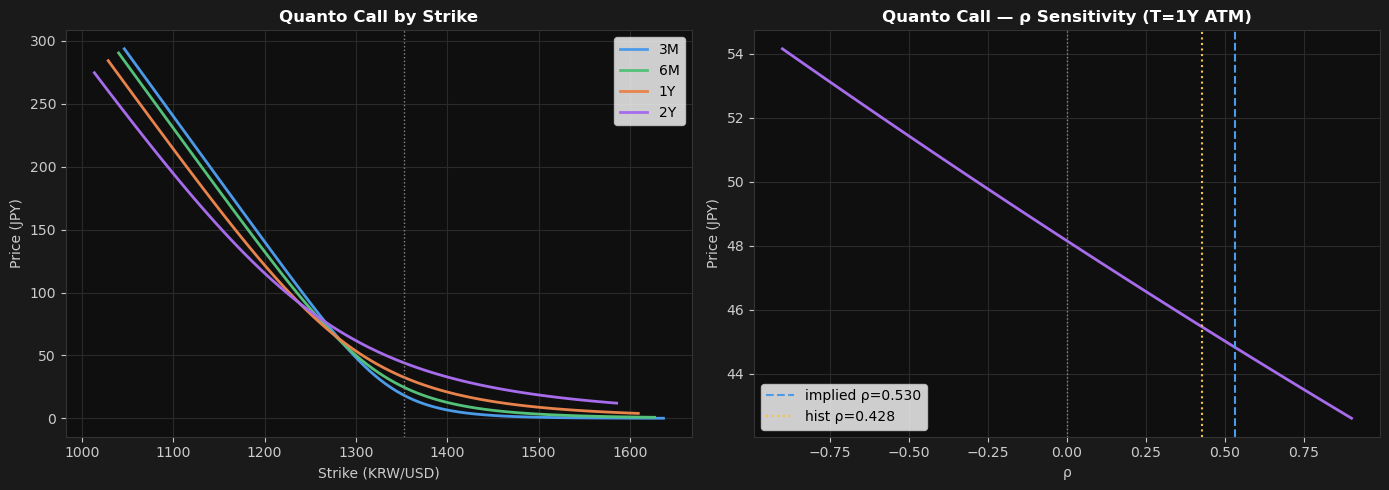

In [16]:
def quanto_forward(K, T_):
    """
    콴토 조정 포워드 — ATM σ₁ 사용 (strike 무관, PCP 보장)
    F_q = F × exp(-ρ · σ₁_ATM · σ₂ · T)
    """
    F_     = float(_iF(T_))
    s1_atm = sigma1(F_, T_)   # ATM σ₁ (드리프트 조정용)
    s2_    = get_sigma2(T_)
    rho_   = get_rho(T_)
    rs_    = rho_ * s1_atm * s2_
    return F_ * np.exp(-rs_ * T_)


def quanto_call(K, T_, use_smile=True):
    """
    USDKRW → JPY Quanto Call (Jewitt p.554)
    - F_q = quanto_forward(K, T_)  ← ATM σ₁ 기반 (strike 무관)
    - df_j = jpy_curve.df(T_)      ← JPY 금리로 할인
    - BS 내부 σ: use_smile=True 이면 SABR smile σ₁(K,T), 아니면 ATM σ₁
    """
    F_q  = quanto_forward(K, T_)
    df_j = jpy_curve.df(T_)
    s1_  = sigma1(K, T_) if use_smile else sigma1(float(_iF(T_)), T_)

    if s1_ * np.sqrt(T_) < 1e-10:
        return df_j * max(F_q - K, 0.0)

    # ===== 구현 =====
    d1 = (np.log(F_q / K) + 0.5 * s1_**2 * T_) / (s1_ * np.sqrt(T_))
    d2 = d1 - s1_ * np.sqrt(T_)
    return df_j * (F_q * norm.cdf(d1) - K * norm.cdf(d2))
    # ================


def quanto_put(K, T_, use_smile=True):
    """Put-Call Parity: P = C - DF_JPY × (F_quanto - K)"""
    F_q  = quanto_forward(K, T_)
    df_j = jpy_curve.df(T_)
    call = quanto_call(K, T_, use_smile=use_smile)
    return call - df_j * (F_q - K)


# ── PCP 검증 ─────────────────────────────────────────────────────────────
print('Put-Call Parity 검증 (C - P - DF×(F_q-K) = 0 이어야 함):')
for T_ in [0.25, 0.5, 1.0, 2.0]:
    F_q = quanto_forward(float(_iF(T_)), T_)
    K   = F_q
    c   = quanto_call(K, T_)
    p   = quanto_put(K, T_)
    pcp = c - p - jpy_curve.df(T_) * (F_q - K) if c and p else float('nan')
    print(f'  T={T_:.2f}  C={c:.4f}  P={p:.4f}  오차={pcp:.2e}')

# 시각화
colors_t = ['#4C9BE8','#54C17A','#E8834C','#A66CEB']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (t_str, T_), c in zip([('3M',3/12),('6M',6/12),('1Y',1.0),('2Y',2.0)], colors_t):
    F_    = float(_iF(T_))
    K_arr = np.linspace(F_*0.78, F_*1.22, 100)
    axes[0].plot(K_arr, [quanto_call(K,T_) for K in K_arr], color=c, lw=2, label=t_str)

axes[0].axvline(S0, color=C['line'], ls=':', lw=1)
stylize(axes[0], 'Quanto Call by Strike', 'Strike (KRW/USD)', 'Price (JPY)')
axes[0].legend()

T_r = 1.0; F_r=float(_iF(T_r)); s1_r=sigma1(F_r,T_r); s2_r=get_sigma2(T_r)
rho_range = np.linspace(-0.9, 0.9, 120)
prices_rho = []
for rh in rho_range:
    rs_ = rh * s1_r * s2_r
    F_q_ = F_r * np.exp(-rs_ * T_r)
    df_j = jpy_curve.df(T_r)
    if s1_r * np.sqrt(T_r) < 1e-10:
        prices_rho.append(df_j * max(F_q_ - F_r, 0))
    else:
        d1=(np.log(F_q_/F_r)+0.5*s1_r**2*T_r)/(s1_r*np.sqrt(T_r))
        d2=d1-s1_r*np.sqrt(T_r)
        from scipy.stats import norm as _n
        prices_rho.append(df_j*(F_q_*_n.cdf(d1)-F_r*_n.cdf(d2)))

axes[1].plot(rho_range, prices_rho, color=C['quanto'], lw=2)
axes[1].axvline(get_rho(T_r), color=C['krw'], ls='--', lw=1.5,
                label=f'implied ρ={get_rho(T_r):.3f}')
axes[1].axvline(rho_hist_val, color=C['hist'], ls=':', lw=1.5,
                label=f'hist ρ={rho_hist_val:.3f}')
axes[1].axvline(0, color=C['line'], ls=':', lw=1)
stylize(axes[1], 'Quanto Call — ρ Sensitivity (T=1Y ATM)', 'ρ', 'Price (JPY)')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## §6. TODO 4 — Spot Log-Euler Update (Monte Carlo)

### 힌트
**SABR β=1 에서 spot의 동학:**
$$\frac{dS}{S} = \left(\text{forward drift} - \rho \cdot \sigma_{1,ATM} \cdot \sigma_2\right)dt + \alpha\,dW$$

**Log-Euler 이산화:**
$$\ln S_{t+dt} = \ln S_t + \left(\ln\frac{F_{t+dt}}{F_t} - \rho\cdot\alpha_i\cdot\sigma_2\cdot dt - \frac{1}{2}\alpha_i^2\,dt\right) + \alpha_i\sqrt{dt}\cdot Z$$

- `drift = log(F_next / F_prev) - quanto_adj` (forward drift + 콴토 조정)
- `quanto_adj = rho_q × a_i × s2_t × dt` (콴토 드리프트 조정항)
- `S_new = S × exp(drift - 0.5 × a_i² × dt + a_i × sqrt(dt) × Z)`
- alpha는 **만기별 deterministic ATM alpha** 사용 권장
  (stochastic alpha는 단기 ν가 커서 발산 위험)

In [17]:
def simulate_quanto_sabr(T_, n_steps=252, n_paths=200_000, seed=42):
    """
    USDKRW → JPY Quanto MC (Log-Euler)

    [주의] alpha를 deterministic ATM값으로 고정
    → 시간가변 σ_ATM(t)를 갖는 lognormal Black 모형
    → ATM 부근 BS와 일치, OTM/ITM은 smile 차이로 괴리 발생
    """
    rng    = np.random.default_rng(seed)
    t_arr  = np.linspace(T_/n_steps, T_, n_steps)
    dt_arr = np.diff(np.concatenate([[0], t_arr]))

    S      = np.full(n_paths, S0)
    F_prev = S0
    S_mat  = np.empty((n_paths, n_steps))
    Z1     = rng.standard_normal((n_paths, n_steps))

    for i, t_next in enumerate(t_arr):
        dt      = dt_arr[i]
        sqrt_dt = np.sqrt(dt)

        a_i, _, _ = sabr_params_at(t_next)   # deterministic ATM alpha
        F_next    = float(_iF(t_next))
        z_s       = Z1[:, i]

        # ── TODO 4: Spot Log-Euler Update ────────────────────────────────
        s2_t       = get_sigma2(t_next)
        rho_q      = get_rho(t_next)
        quanto_adj = rho_q * a_i * s2_t * dt   # ← 콴토 핵심 조정

        # ===== 구현 =====
        # forward drift = log(F_next/F_prev), 여기서 콴토 조정 차감
        drift = np.log(F_next / F_prev) - quanto_adj
        S     = S * np.exp(drift - 0.5 * a_i**2 * dt + a_i * sqrt_dt * z_s)
        S     = np.maximum(S, 1e-6)
        # ================

        S_mat[:, i] = S
        F_prev = F_next

    return S_mat, t_arr

# ── MC 실행 ──────────────────────────────────────────────────────────────
T_MC = 1.0
S_mat, t_arr = simulate_quanto_sabr(T_MC)

F_1y  = float(_iF(T_MC))
s1_1y = sigma1(F_1y, T_MC); s2_1y = get_sigma2(T_MC); rho_1y = get_rho(T_MC)
F_q   = F_1y * np.exp(-rho_1y * s1_1y * s2_1y * T_MC)

print(f'MC 완료: 200,000 paths × 252 steps')
print(f'E[S_T] MC  = {S_mat[:,-1].mean():,.2f}')
print(f'F_quanto   = {F_q:,.2f}')
print(f'bias       = {(S_mat[:,-1].mean()-F_q)/F_q*100:+.4f}%')
print()
print('--- MC 자가 진단 ---')
log_ret = np.diff(np.log(S_mat), axis=1)
realized_vol = log_ret.std(axis=0).mean() * np.sqrt(TRADING_DAYS)
target_vol   = sabr_params_at(T_MC)[0]
print(f'MC Realized Vol : {realized_vol:.4f}  ({realized_vol*100:.2f}%)')
print(f'Target SABR Vol : {target_vol:.4f}  ({target_vol*100:.2f}%)')
print('--------------------')

MC 완료: 200,000 paths × 252 steps
E[S_T] MC  = 1,313.20
F_quanto   = 1,312.36
bias       = +0.0639%

--- MC 자가 진단 ---
MC Realized Vol : 0.0876  (8.76%)
Target SABR Vol : 0.0885  (8.85%)
--------------------


MC Realized Vol : 0.0876  (8.76%)
Target SABR Vol : 0.0885  (8.85%)
--------------------


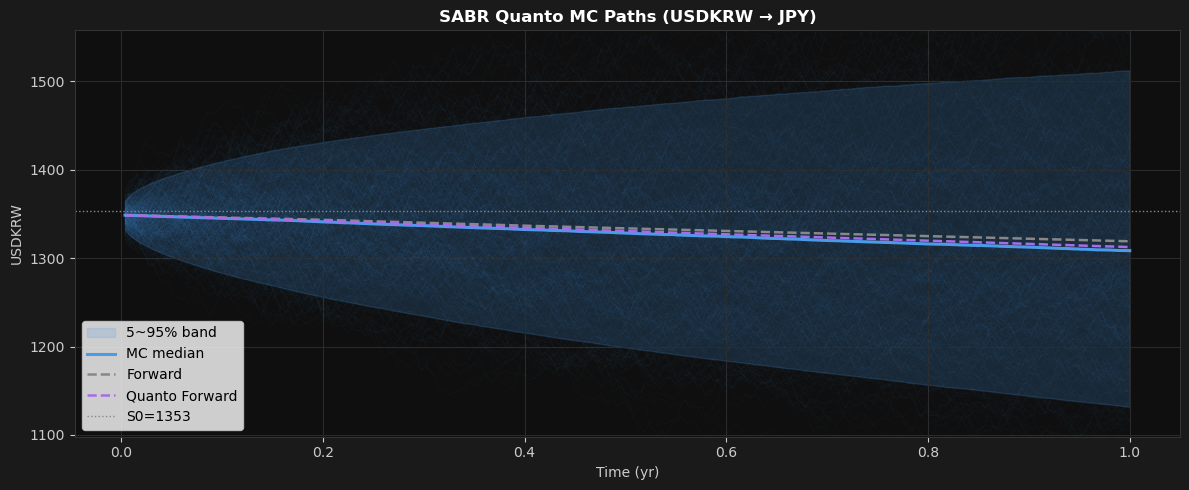

In [18]:
# ── 경로 시각화 ──────────────────────────────────────────────────────────
q05, q50, q95 = np.percentile(S_mat, [5, 50, 95], axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_arr, S_mat[:300].T, color=C['krw'], alpha=0.04, lw=0.6)
ax.fill_between(t_arr, q05, q95, color=C['krw'], alpha=0.18, label='5~95% band')
ax.plot(t_arr, q50, color=C['krw'], lw=2.2, label='MC median')
ax.plot(t_arr, [float(_iF(t)) for t in t_arr],
        color=C['line'], lw=1.8, ls='--', label='Forward')
ax.plot(t_arr, [float(_iF(t))*np.exp(-get_rho(t)*sigma1(float(_iF(t)),t)*get_sigma2(t)*t)
                for t in t_arr],
        color=C['quanto'], lw=1.8, ls='--', label='Quanto Forward')
ax.axhline(S0, color=C['line'], lw=1, ls=':', label=f'S0={S0:.0f}')
ax.set_ylim(q05.min()*0.97, q95.max()*1.03)
stylize(ax, 'SABR Quanto MC Paths (USDKRW → JPY)', 'Time (yr)', 'USDKRW')
ax.legend(); plt.tight_layout(); plt.show()

  ATM Quanto Call 비교  (T=1Y)
  F (일반 포워드)  :  1318.9000
  K_atm (F_quanto) :  1312.3563
  BS closed-form   :    47.669747  (SABR smile)
  MC (200K paths)  :    46.485809  ±0.159835
  차이 (MC−BS)     :    -1.183938

[검증 한계]
  MC: deterministic ATM alpha → smile 없음
  BS: SABR smile σ₁(K,T) 반영
  → ATM 일치는 설계상 당연, OTM/ITM에서 차이 발생


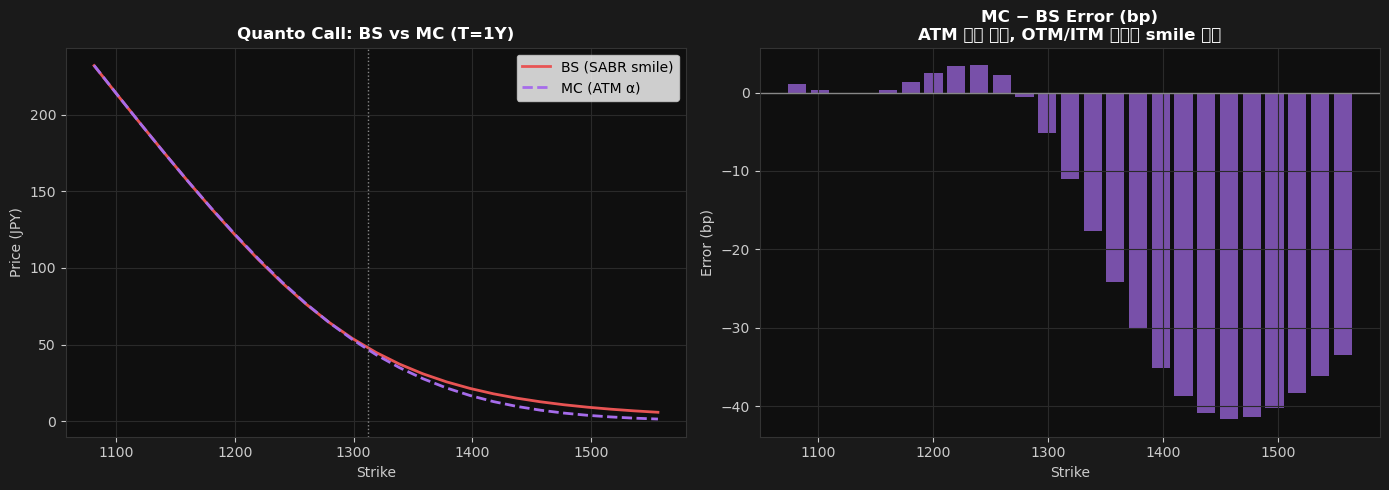

In [19]:
# ── BS vs MC 비교 ────────────────────────────────────────────────────────
def mc_call(K, df_jpy):
    p = np.maximum(S_mat[:,-1] - K, 0)
    return df_jpy*p.mean(), df_jpy*p.std(ddof=1)/np.sqrt(len(p))

F_atm   = float(_iF(T_MC))
s1_atm  = sigma1(F_atm, T_MC)
s2_atm  = get_sigma2(T_MC)
rho_atm = get_rho(T_MC)
K_atm   = F_atm * np.exp(-rho_atm * s1_atm * s2_atm * T_MC)  # F_quanto = ATM

bs_atm = quanto_call(K_atm, T_MC)
mc_atm, mc_se = mc_call(K_atm, jpy_curve.df(T_MC))

print('='*54)
print('  ATM Quanto Call 비교  (T=1Y)')
print('='*54)
print(f'  F (일반 포워드)  : {F_atm:>10.4f}')
print(f'  K_atm (F_quanto) : {K_atm:>10.4f}')
print(f'  BS closed-form   : {bs_atm:>12.6f}  (SABR smile)')
print(f'  MC (200K paths)  : {mc_atm:>12.6f}  ±{mc_se:.6f}')
print(f'  차이 (MC−BS)     : {mc_atm-bs_atm:>+12.6f}')
print('='*54)
print()
print('[검증 한계]')
print('  MC: deterministic ATM alpha → smile 없음')
print('  BS: SABR smile σ₁(K,T) 반영')
print('  → ATM 일치는 설계상 당연, OTM/ITM에서 차이 발생')

K_grid = np.linspace(F_atm*0.82, F_atm*1.18, 25)
df_j   = jpy_curve.df(T_MC)
bs_v   = [quanto_call(K, T_MC) for K in K_grid]
mc_v   = [mc_call(K, df_j)[0]  for K in K_grid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_grid, bs_v, color=C['bs'],     lw=2, label='BS (SABR smile)')
axes[0].plot(K_grid, mc_v, color=C['quanto'], lw=2, ls='--', label='MC (ATM α)')
axes[0].axvline(K_atm, color=C['line'], ls=':', lw=1)
stylize(axes[0], 'Quanto Call: BS vs MC (T=1Y)', 'Strike', 'Price (JPY)')
axes[0].legend()

err = [(m-b)/F_atm*1e4 for m,b in zip(mc_v,bs_v)]
axes[1].bar(K_grid, err, width=(K_grid[1]-K_grid[0])*0.8,
            color=C['quanto'], alpha=0.7)
axes[1].axhline(0, color=C['line'], lw=1)
stylize(axes[1], 'MC − BS Error (bp)\nATM 부근 일치, OTM/ITM 발산은 smile 차이',
        'Strike', 'Error (bp)')
plt.tight_layout(); plt.show()

---
## §7. TODO 5 — Greeks 산출 (Finite Difference)

### 힌트
**Delta**: S0를 ±bump하여 포워드도 함께 이동시킨 후 가격 재계산
$$\Delta = \frac{C(S_0+h) - C(S_0-h)}{2h}$$

**SABR Shadow Vega**: σ₁에 직접 bump하지 않고 **α를 ±1bp bump** → smile 곡면 전체 재계산
$$\text{Vega}_1 = \frac{C(\alpha+0.0001) - C(\alpha-0.0001)}{2 \times 0.0001} \times 0.01$$

**Vega₂**: σ₂(JPYKRW vol)을 ±bump
$$\text{Vega}_2 = \frac{C(\sigma_2+h) - C(\sigma_2-h)}{2h \times 100}$$

**ρ-Vega**: ρ를 ±1% bump (콴토 구조의 유일한 미헷지 리스크)
$$\text{ρ-Vega} = \frac{C(\rho+0.01) - C(\rho-0.01)}{0.02}$$

  Quanto Call Greeks  (ATM=F_quanto, T=1Y)
  Price                    =    47.669747
  Delta  (∂C/∂S₀)         =     0.518633
  Vega₁  SABR Shadow       =     5.048863  (α±1bp, per 1% vol)
  Vega₂  (∂C/∂σ₂ per 1%)  =    -0.328546
  ρ-Vega (∂C/∂ρ per 1%)   =    -6.349919  ← 콴토 핵심 리스크


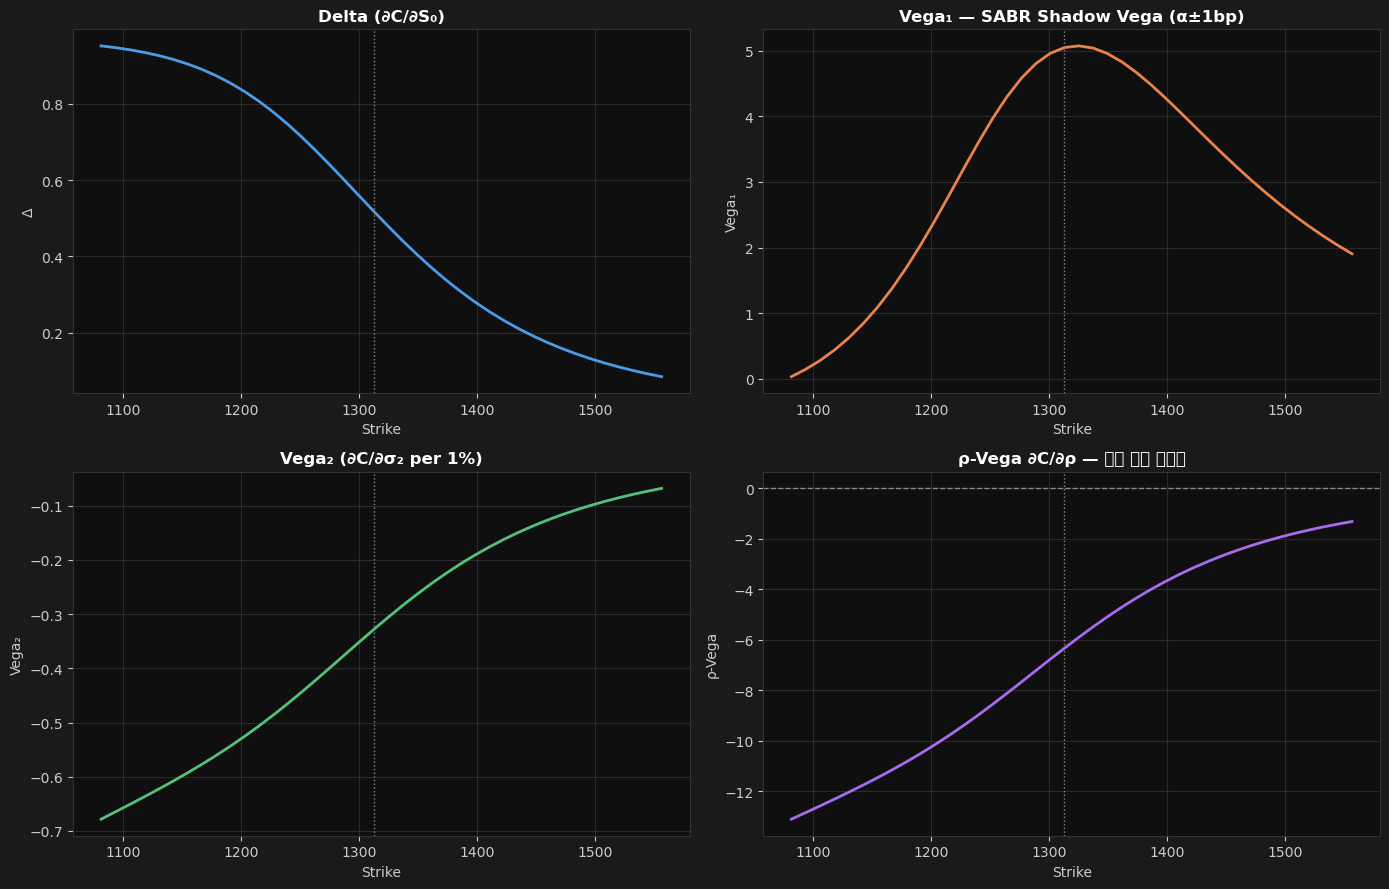

In [20]:
def greeks_quanto(K, T_, bump_pct=0.01):
    """
    수치 그릭스 (Finite Difference)
    - Delta    : S0 bump → Forward 함께 이동
    - Vega₁   : SABR Shadow Vega (α bump → smile 곡면 전체 재계산)
    - Vega₂   : σ₂ bump (SABR 외부 파라미터)
    - ρ-Vega  : ρ bump (콴토 핵심 리스크)
    """
    P0 = quanto_call(K, T_)

    # ── Delta: S0 bump → Forward도 함께 이동 ─────────────────────────────
    h_S = S0 * bump_pct

    def px_delta(S0_):
        F_   = S0_ * usd.df(T_) / krw.df(T_)
        s1_  = sigma1(K, T_)
        s2_  = get_sigma2(T_); rho_=get_rho(T_)
        F_q  = F_ * np.exp(-rho_*s1_*s2_*T_)
        df_j = jpy_curve.df(T_)
        if s1_*np.sqrt(T_)<1e-10: return df_j*max(F_q-K,0)
        d1=(np.log(F_q/K)+0.5*s1_**2*T_)/(s1_*np.sqrt(T_))
        d2=d1-s1_*np.sqrt(T_)
        return df_j*(F_q*norm.cdf(d1)-K*norm.cdf(d2))

    # ===== 구현 =====
    delta = (px_delta(S0 + h_S) - px_delta(S0 - h_S)) / (2 * h_S)
    # ================

    # ── Vega₁: SABR Shadow Vega (α bump) ─────────────────────────────────
    h_alpha = 0.0001   # 1bp

    def px_vega1(d_alpha):
        F_   = float(_iF(T_))
        a_base, r_sabr, v_sabr = sabr_params_at(T_)
        a_bumped = max(a_base + d_alpha, 1e-8)
        s1_  = sabr_vol(F_, K, T_, a_bumped, BETA, r_sabr, v_sabr)
        s2_  = get_sigma2(T_); rho_=get_rho(T_)
        F_q  = F_ * np.exp(-rho_*s1_*s2_*T_)
        df_j = jpy_curve.df(T_)
        if s1_*np.sqrt(T_)<1e-10: return df_j*max(F_q-K,0)
        d1=(np.log(F_q/K)+0.5*s1_**2*T_)/(s1_*np.sqrt(T_))
        d2=d1-s1_*np.sqrt(T_)
        return df_j*(F_q*norm.cdf(d1)-K*norm.cdf(d2))

    # ===== 구현 =====
    # α ±1bp bump → smile 곡면 전체 이동 (Shadow Vega), per 1% vol 환산
    vega1 = (px_vega1(+h_alpha) - px_vega1(-h_alpha)) / (2*h_alpha) * 0.01
    # ================

    # ── Vega₂: σ₂ bump ───────────────────────────────────────────────────
    h_s2 = get_sigma2(T_) * bump_pct

    def px_vega2(ds2):
        F_   = float(_iF(T_)); s1_=sigma1(K,T_)
        s2_  = get_sigma2(T_)+ds2; rho_=get_rho(T_)
        F_q  = F_*np.exp(-rho_*s1_*s2_*T_)
        df_j = jpy_curve.df(T_)
        if s1_*np.sqrt(T_)<1e-10: return df_j*max(F_q-K,0)
        d1=(np.log(F_q/K)+0.5*s1_**2*T_)/(s1_*np.sqrt(T_))
        d2=d1-s1_*np.sqrt(T_)
        return df_j*(F_q*norm.cdf(d1)-K*norm.cdf(d2))

    # ===== 구현 =====
    # per 1% vol 환산: 2*h_s2 로 미분 후 ×0.01  →  ÷(2*h_s2)*0.01 == ÷(2*h_s2*100)
    vega2 = (px_vega2(+h_s2) - px_vega2(-h_s2)) / (2*h_s2*100)
    # ================

    # ── ρ-Vega: ρ bump ───────────────────────────────────────────────────
    h_rho = 0.01

    def px_rho(drho):
        F_   = float(_iF(T_)); s1_=sigma1(K,T_); s2_=get_sigma2(T_)
        rho_ = float(np.clip(get_rho(T_)+drho,-0.9999,0.9999))
        F_q  = F_*np.exp(-rho_*s1_*s2_*T_)
        df_j = jpy_curve.df(T_)
        if s1_*np.sqrt(T_)<1e-10: return df_j*max(F_q-K,0)
        d1=(np.log(F_q/K)+0.5*s1_**2*T_)/(s1_*np.sqrt(T_))
        d2=d1-s1_*np.sqrt(T_)
        return df_j*(F_q*norm.cdf(d1)-K*norm.cdf(d2))

    # ===== 구현 =====
    rho_vega = (px_rho(+h_rho) - px_rho(-h_rho)) / (2*h_rho)
    # ================

    return {'price':P0,'delta':delta,'vega1':vega1,'vega2':vega2,'rho_vega':rho_vega}

# ── ATM Greeks 출력 ───────────────────────────────────────────────────────
g = greeks_quanto(K_atm, T_MC)

print('='*58)
print('  Quanto Call Greeks  (ATM=F_quanto, T=1Y)')
print('='*58)
print(f'  Price                    = {g["price"]:>12.6f}')
print(f'  Delta  (∂C/∂S₀)         = {g["delta"]:>12.6f}')
print(f'  Vega₁  SABR Shadow       = {g["vega1"]:>12.6f}  (α±1bp, per 1% vol)')
print(f'  Vega₂  (∂C/∂σ₂ per 1%)  = {g["vega2"]:>12.6f}')
print(f'  ρ-Vega (∂C/∂ρ per 1%)   = {g["rho_vega"]:>12.6f}  ← 콴토 핵심 리스크')
print('='*58)

# Strike별 Greeks 프로파일
K_g   = np.linspace(F_atm*0.82, F_atm*1.18, 40)
G_all = [greeks_quanto(K, T_MC) for K in K_g]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0,0].plot(K_g,[g['delta']    for g in G_all],color=C['krw'],lw=2)
axes[0,0].axvline(K_atm,color=C['line'],ls=':',lw=1)
stylize(axes[0,0],'Delta (∂C/∂S₀)','Strike','Δ')

axes[0,1].plot(K_g,[g['vega1']    for g in G_all],color=C['mc'],lw=2)
axes[0,1].axvline(K_atm,color=C['line'],ls=':',lw=1)
stylize(axes[0,1],'Vega₁ — SABR Shadow Vega (α±1bp)','Strike','Vega₁')

axes[1,0].plot(K_g,[g['vega2']    for g in G_all],color=C['jpy'],lw=2)
axes[1,0].axvline(K_atm,color=C['line'],ls=':',lw=1)
stylize(axes[1,0],'Vega₂ (∂C/∂σ₂ per 1%)','Strike','Vega₂')

axes[1,1].plot(K_g,[g['rho_vega'] for g in G_all],color=C['quanto'],lw=2)
axes[1,1].axhline(0,color=C['line'],lw=1,ls='--')
axes[1,1].axvline(K_atm,color=C['line'],ls=':',lw=1)
stylize(axes[1,1],'ρ-Vega ∂C/∂ρ — 콴토 핵심 리스크','Strike','ρ-Vega')
plt.tight_layout(); plt.show()

---
## §8. 결과 요약 & 해석

In [21]:
rows = []
for T_ in [1/12, 3/12, 6/12, 1.0, 2.0]:
    F_ = float(_iF(T_))
    for label, K in [('80%',F_*0.8),('ATM',F_),('120%',F_*1.2)]:
        s1_=sigma1(K,T_); s2_=get_sigma2(T_); rho_=get_rho(T_)
        F_q_=F_*np.exp(-rho_*s1_*s2_*T_)
        rows.append({'T(yr)':round(T_,4),'Strike':label,
                     'F':round(F_,1),'F_quanto':round(F_q_,1),
                     'σ₁(%)':round(s1_*100,3),'σ₂(%)':round(s2_*100,3),
                     'ρ':round(rho_,4),'Call(JPY)':round(quanto_call(K,T_),6)})

print(pd.DataFrame(rows).to_string(index=False))

print(f'\n{"="*58}')
print('  핵심 해석 (Jewitt p.554)')
print(f'{"="*58}')
rho_1y=get_rho(1.0); s1_1y=sigma1(float(_iF(1.0)),1.0); s2_1y=get_sigma2(1.0)
sign='양(+)' if rho_1y>0 else '음(-)'
direction='하락 → 콴토 call < plain call' if rho_1y>0 else '상승 → 콴토 call > plain call'
print(f'  implied ρ (1Y)         = {rho_1y:+.4f}  [{sign}]')
print(f'  → 콴토 포워드 {direction}')
print(f'  σ₂ (JPYKRW, 1Y)        = {s2_1y*100:.2f}%')
print(f'  ρ·σ₁·σ₂ (1Y)           = {rho_1y*s1_1y*s2_1y:.6f}  (연간 드리프트 조정)')
print(f'  implied vs hist ρ 차이  = {rho_1y-rho_hist_val:+.4f}')
print(f'{"="*58}')

 T(yr) Strike      F  F_quanto  σ₁(%)  σ₂(%)      ρ  Call(JPY)
0.0833    80% 1346.3    1345.3 16.827  9.500 0.5872 268.722231
0.0833    ATM 1346.3    1345.8  8.979  9.500 0.5872  13.640777
0.0833   120% 1346.3    1345.3 17.108  9.500 0.5872   0.001886
0.2500    80% 1341.5    1339.3 13.084  9.800 0.5044 266.882503
0.2500    ATM 1341.5    1340.0  8.850  9.800 0.5044  22.944938
0.2500   120% 1341.5    1339.2 14.071  9.800 0.5044   0.147895
0.5000    80% 1333.5    1329.5 11.489 10.102 0.5131 263.780110
0.5000    ATM 1333.5    1330.4  8.980 10.102 0.5131  32.217034
0.5000   120% 1333.5    1329.0 13.007 10.102 0.5131   1.116000
1.0000    80% 1318.9    1311.5 10.325 10.250 0.5303 258.155994
1.0000    ATM 1318.9    1312.4  9.150 10.250 0.5303  44.834352
1.0000   120% 1318.9    1310.2 12.198 10.250 0.5303   4.746837
2.0000    80% 1299.5    1284.6  9.867 10.323 0.5649 249.974688
2.0000    ATM 1299.5    1285.2  9.458 10.323 0.5649  61.971691
2.0000   120% 1299.5    1281.9 11.638 10.323 0.5649  13